# Verification: AFOLU Fluxes from Gridded Extension

Read the gridded extension output (from notebook 03) and recompute AFOLU CO₂ fluxes
using the same cohort-based model calibrated in notebook 02. Confirm that the implied
fluxes match the IAM target trajectory.

This closes the loop:
- **Notebook 02**: Calibrate model → derive AFOLU-consistent ramp $r(t)$
- **Notebook 03**: Apply $r(t)$ to produce gridded extension files
- **Notebook 04** (this): Read gridded files → recompute fluxes → verify match

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    load_states,
)
from src import carbon_model as cm

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load IAM Target and Calibration Parameters

In [8]:
df = load_csv()
sc = filter_scenario(df)
afolu_target = get_variable(sc, 'Emissions|CO2|AFOLU')

# Load calibration parameters from notebook 02
cal = np.load(cfg.OUTPUT_DIR / 'afolu_calibration.npz')
tau_opt = float(cal['tau'])
beta = float(cal['beta'])
gamma = float(cal['gamma'])
alpha_trans = float(cal['alpha_trans'])
alpha_stock = float(cal['alpha_stock'])
r_derived = cal['ramp']
ext_years = cal['years']

print(f'Calibration: τ={tau_opt:.0f} yr, β={beta:.1f}, γ={gamma:.0f}/decade')
print(f'             α_trans={alpha_trans:.3f}, α_stock={alpha_stock:.3f}')
print(f'Ramp: {ext_years[0]}–{ext_years[-1]}, range [{r_derived.min():.4f}, {r_derived.max():.4f}]')

Calibration: τ=35 yr, β=-388.0, γ=-737/decade
             α_trans=0.111, α_stock=0.375
Ramp: 2101–2500, range [0.0000, 0.9765]


## 2. Load Gridded Data

Open the extension output from notebook 03 and the original input for the pre-2100 period.

In [9]:
# Find the states extension file
import glob
ext_files = sorted(glob.glob(str(cfg.OUTPUT_DIR / '*_extension_transient_2101-*.nc')))
states_ext_file = [f for f in ext_files if 'states' in f.lower() or 'step4' in f.lower()]
if not states_ext_file:
    raise FileNotFoundError(f'No states extension file in {cfg.OUTPUT_DIR}')
states_ext_file = states_ext_file[0]
print(f'Extension file: {os.path.basename(states_ext_file)}')

ds_ext = xr.open_dataset(states_ext_file)
ds_input = load_states()

lat = ds_ext.lat.values
lon = ds_ext.lon.values
ramp_years = ds_ext.time.values.astype(int)

# Grid-cell area (km²)
R_EARTH = 6371.0
dlat = np.abs(np.diff(lat[:2]))[0]
dlon = np.abs(np.diff(lon[:2]))[0]
lat_rad = np.deg2rad(lat)
cell_area = (R_EARTH**2) * np.deg2rad(dlat) * np.deg2rad(dlon) * np.cos(lat_rad)
cell_area_2d = np.broadcast_to(cell_area[:, np.newaxis], (len(lat), len(lon)))

print(f'Extension: {ramp_years[0]}–{ramp_years[-1]} ({len(ramp_years)} years)')
print(f'Grid: {len(lat)} × {len(lon)}')

Extension file: output_annual_2024_states_step4_extension_transient_2101-2142.nc
Extension: 2101–2142 (42 years)
Grid: 720 × 1440


## 3. Carbon Density Parameters

Same values as notebook 02 — these must match for the verification to be meaningful.

In [ ]:
# Import carbon cycle parameters from the model module
CARBON_DENSITY = cm.CARBON_DENSITY
C_EQ = cm.C_EQ
REGROW_VARS = cm.REGROW_VARS
TC_TO_MTCO2 = cm.TC_TO_MTCO2

print(f'Regrowing types: {REGROW_VARS}')

Regrowing types: ['secdf', 'secdn', 'pltns']


## 4. Compute AFOLU Fluxes from Gridded Extension

Read the actual gridded extension fields and compute transition and stock-change fluxes.
This is the independent check — we use the gridded data, not the analytical forward solve.

In [11]:
%%time
# ─── Pre-2100: transition flux and area increments ───
input_years = ds_input.time.values.astype(int)
n_input = len(input_years)
input_flux_years = input_years[1:]
n_pre = len(input_flux_years)

# Time trend (must match notebook 02 exactly)
time_trend_pre = (input_flux_years - input_flux_years.mean()) / 10.0
time_2100 = (2100 - input_flux_years.mean()) / 10.0

transition_flux_pre = np.zeros(n_pre)
area_incr_pre = {v: np.zeros(n_pre) for v in REGROW_VARS}

for ti in range(1, n_input):
    af = 0.0
    for v in cfg.STATE_VARS:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        af += np.nansum(-delta * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    transition_flux_pre[ti-1] = af
    for v in REGROW_VARS:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        area_incr_pre[v][ti-1] = np.nansum(delta * cell_area_2d)

# ─── Extension period: transition flux and area increments ───
vals_2100 = {v: ds_input[v].isel(time=-1).values for v in cfg.STATE_VARS}
n_ramp = len(ramp_years)
full_ext_years = np.arange(cfg.YR_END_INPUT + 1, cfg.YR_END_OUTPUT + 1)
n_ext = len(full_ext_years)

ext_transition = np.zeros(n_ext)
area_incr_ext = {v: np.zeros(n_ext) for v in REGROW_VARS}

for ti in range(n_ramp):
    af = 0.0
    for v in cfg.STATE_VARS:
        prev = vals_2100[v] if ti == 0 else ds_ext[v].isel(time=ti-1).values
        curr = ds_ext[v].isel(time=ti).values
        delta = curr - prev
        af += np.nansum(-delta * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    ext_transition[ti] = af
    for v in REGROW_VARS:
        prev = vals_2100[v] if ti == 0 else ds_ext[v].isel(time=ti-1).values
        curr = ds_ext[v].isel(time=ti).values
        area_incr_ext[v][ti] = np.nansum((curr - prev) * cell_area_2d)

# ─── Stock-change flux via cohort convolution ───
decay = np.exp(-1.0 / tau_opt)
stock_flux_pre = np.zeros(n_pre)
G_state = {v: 0.0 for v in REGROW_VARS}

for t in range(n_pre):
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0:
            continue
        G_state[v] = G_state[v] * decay + area_incr_pre[v][t]
        stock_flux_pre[t] += -(ceq / tau_opt) * G_state[v] * TC_TO_MTCO2

ext_stock = np.zeros(n_ext)
for t in range(n_ext):
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0:
            continue
        G_state[v] = G_state[v] * decay + area_incr_ext[v][t]
        ext_stock[t] += -(ceq / tau_opt) * G_state[v] * TC_TO_MTCO2

# ─── Calibrated total (Model D: β + γ·t + α_trans·F_trans + α_stock·F_stock) ───
ramp_for_ext = np.zeros(n_ext)
ramp_for_ext[:len(r_derived)] = r_derived[:n_ext]

# Pre-2100: full 4-predictor model
calibrated_pre = (beta + gamma * time_trend_pre
                  + alpha_trans * transition_flux_pre
                  + alpha_stock * stock_flux_pre)

# Post-2100: baseline frozen at β + γ·t₂₁₀₀ (matches notebook 02 forward solve)
baseline = beta + gamma * time_2100
ext_calib = (baseline * ramp_for_ext
             + alpha_trans * ext_transition
             + alpha_stock * ext_stock)

print(f'Pre-2100: {n_pre} years, Extension: {n_ext} years')
print(f'Baseline (β + γ·t₂₁₀₀) = {baseline:.0f} Mt CO₂/yr')
print(f'Transition flux range (ext): [{ext_transition.min():.0f}, {ext_transition.max():.0f}]')
print(f'Stock flux range (ext): [{ext_stock.min():.0f}, {ext_stock.max():.0f}]')

Pre-2100: 76 years, Extension: 400 years
Baseline (β + γ·t₂₁₀₀) = -3153 Mt CO₂/yr
Transition flux range (ext): [-646, 339]
Stock flux range (ext): [-4133, -0]
CPU times: user 29 s, sys: 2.16 s, total: 31.1 s
Wall time: 31.3 s


## 5. Verification: Gridded Fluxes vs IAM Target

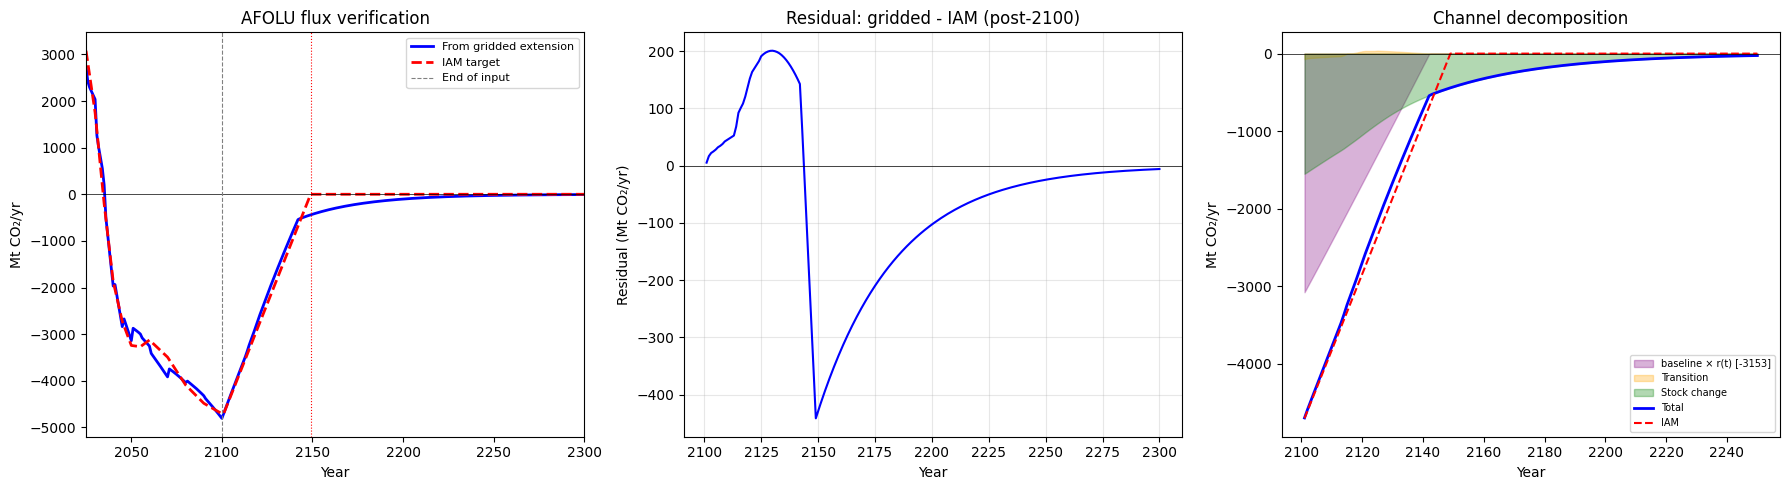


Post-2100 verification (during ramp):
  RMSE: 162.2 Mt CO₂/yr
  Max |residual|: 441.2 Mt CO₂/yr
  WARN: large residuals


In [12]:
# Full timeseries
all_years = np.concatenate([input_flux_years, full_ext_years])
all_calib = np.concatenate([calibrated_pre, ext_calib])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: full timeseries
ax = axes[0]
ax.plot(all_years, all_calib, 'b-', lw=2, label='From gridded extension')
afolu_plot = afolu_target.loc[2025:2300]
ax.plot(afolu_plot.index, afolu_plot.values, 'r--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_END_INPUT, color='gray', ls='--', lw=0.8, label='End of input')
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU flux verification')
ax.legend(fontsize=8); ax.set_xlim(2025, 2300)

# Middle: residual post-2100
ax = axes[1]
iam_ext_vals = np.array([afolu_target.loc[yr] if yr in afolu_target.index else 0.0
                          for yr in full_ext_years])
residual = ext_calib - iam_ext_vals
ax.plot(full_ext_years[:200], residual[:200], 'b-', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Residual (Mt CO₂/yr)')
ax.set_title('Residual: gridded - IAM (post-2100)')
ax.grid(True, alpha=0.3)

# Right: channel decomposition (baseline = β + γ·t₂₁₀₀, frozen post-2100)
ax = axes[2]
baseline_comp = baseline * ramp_for_ext
trans_comp = alpha_trans * ext_transition
stock_comp = alpha_stock * ext_stock
ax.fill_between(full_ext_years[:150], 0, baseline_comp[:150],
                alpha=0.3, color='purple', label=f'baseline × r(t) [{baseline:.0f}]')
ax.fill_between(full_ext_years[:150], 0, trans_comp[:150],
                alpha=0.3, color='orange', label='Transition')
ax.fill_between(full_ext_years[:150], 0, stock_comp[:150],
                alpha=0.3, color='green', label='Stock change')
ax.plot(full_ext_years[:150], ext_calib[:150], 'b-', lw=2, label='Total')
ax.plot(full_ext_years[:150], iam_ext_vals[:150], 'r--', lw=1.5, label='IAM')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Channel decomposition')
ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# Quantitative check
ramp_mask = full_ext_years <= cfg.YR_AFOLU_ZERO
rmse_ramp = np.sqrt(np.mean(residual[ramp_mask]**2))
max_resid = np.max(np.abs(residual[ramp_mask]))
print(f'\nPost-2100 verification (during ramp):')
print(f'  RMSE: {rmse_ramp:.1f} Mt CO₂/yr')
print(f'  Max |residual|: {max_resid:.1f} Mt CO₂/yr')
print(f'  PASS' if rmse_ramp < 100 else f'  WARN: large residuals')

## 6. Per-Cell Conservation Check

Verify that state fractions sum to 1.0 on every land cell at every extension timestep.

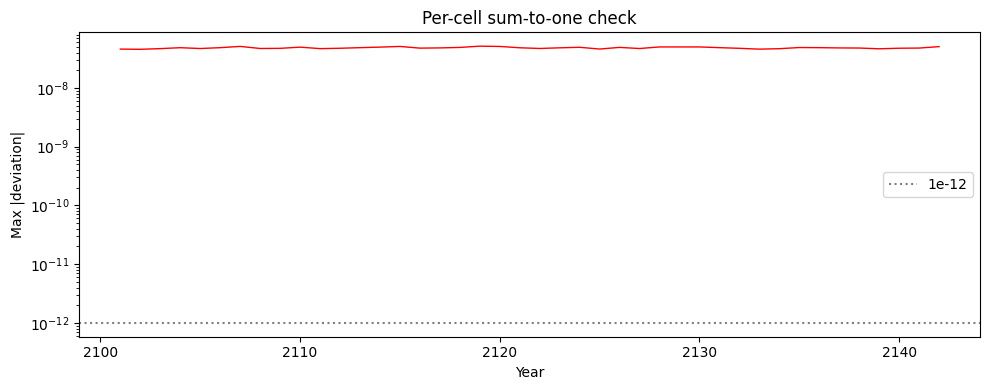

Max deviation: 5.14e-08
WARN: deviations exceed tolerance


In [13]:
cell_total_2100 = np.zeros_like(vals_2100['primf'])
for v in cfg.STATE_VARS:
    cell_total_2100 += np.where(np.isfinite(vals_2100[v]), vals_2100[v], 0.0)
land_mask = np.isfinite(vals_2100['secdf'])

max_dev = np.zeros(n_ramp)
for ti in range(n_ramp):
    cell_sum = np.zeros_like(vals_2100['primf'])
    for v in cfg.STATE_VARS:
        cell_sum += np.where(np.isfinite(ds_ext[v].isel(time=ti).values),
                              ds_ext[v].isel(time=ti).values, 0.0)
    dev_land = np.abs(cell_sum - cell_total_2100)[land_mask]
    max_dev[ti] = np.max(dev_land)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(ramp_years, max_dev, 'r-', lw=1)
ax.axhline(1e-12, color='gray', ls=':', label='1e-12')
ax.set_xlabel('Year'); ax.set_ylabel('Max |deviation|')
ax.set_title('Per-cell sum-to-one check'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Max deviation: {max_dev.max():.2e}')
print(f'PASS' if max_dev.max() < 1e-10 else 'WARN: deviations exceed tolerance')

## 7. Spatial Patterns at Key Years

Mapping flux at years: [2110, 2130, 2142]
Extension data covers: 2101–2142 (42 years)
cell_area_2d: shape=(720, 1440), finite=1036800, NaN=0

Diagnostic for year 2110 (ti=9):
  secdf: prev finite=209187, curr finite=209187
  secdf: delta finite=209187, delta range=[-0.021444, 0.020938]
  secdf: flux finite=209187, flux range=[-0.350663, 0.455348]

  2110 (ti=9): Finite=1036800, Nonzero=239074
    Flux range: [-0.2879, 0.4261], mean=-0.0003, vmax=±0.1000
  2130 (ti=29): Finite=1036800, Nonzero=239072
    Flux range: [-0.0540, 0.1837], mean=0.0003, vmax=±0.1000
  2142 (ti=41): Finite=1036800, Nonzero=239022
    Flux range: [-0.0003, 0.0010], mean=0.0000, vmax=±0.1000


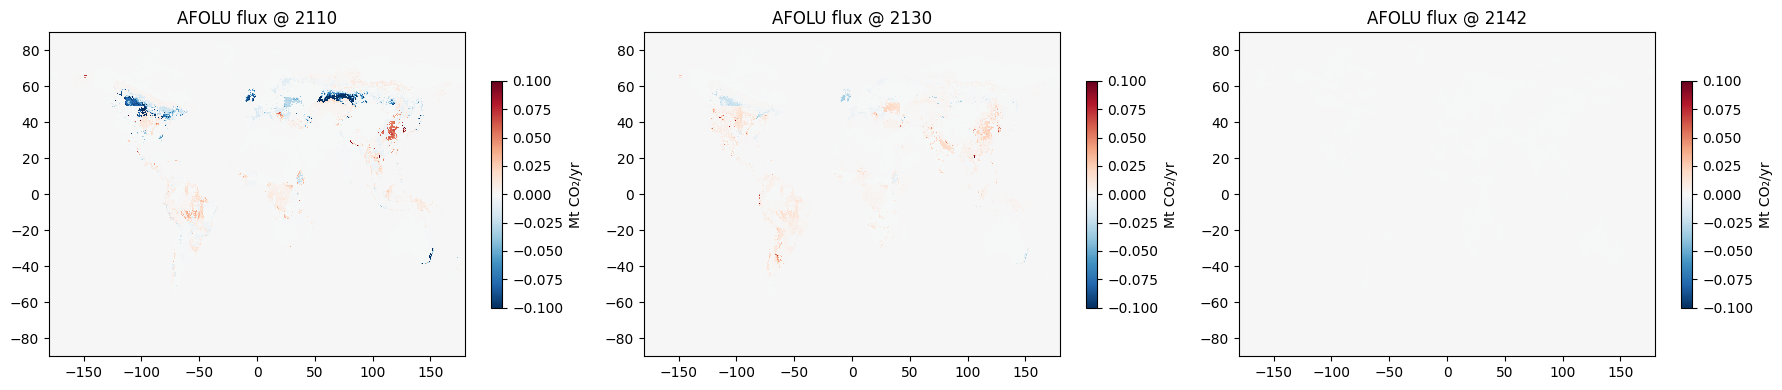

In [25]:
map_years = [2110, 2130, int(ramp_years[-1])]
fig, axes = plt.subplots(1, len(map_years), figsize=(6 * len(map_years), 4))

print(f"Mapping flux at years: {map_years}")
print(f"Extension data covers: {ramp_years[0]}–{ramp_years[-1]} ({len(ramp_years)} years)")
print(f"cell_area_2d: shape={cell_area_2d.shape}, finite={np.sum(np.isfinite(cell_area_2d))}, NaN={np.sum(np.isnan(cell_area_2d))}\n")

# Test year
test_yr = 2110
test_ti = min(np.searchsorted(ramp_years, test_yr), len(ramp_years) - 1)
print(f"Diagnostic for year {test_yr} (ti={test_ti}):")
test_v = 'secdf'
test_prev = vals_2100[test_v] if test_ti == 0 else ds_ext[test_v].isel(time=test_ti-1).values
test_curr = ds_ext[test_v].isel(time=test_ti).values
test_delta = test_curr - test_prev
print(f"  {test_v}: prev finite={np.sum(np.isfinite(test_prev))}, curr finite={np.sum(np.isfinite(test_curr))}")
print(f"  {test_v}: delta finite={np.sum(np.isfinite(test_delta))}, delta range=[{np.nanmin(test_delta):.6f}, {np.nanmax(test_delta):.6f}]")
test_flux = -test_delta * CARBON_DENSITY[test_v] * cell_area_2d * TC_TO_MTCO2
print(f"  {test_v}: flux finite={np.sum(np.isfinite(test_flux))}, flux range=[{np.nanmin(test_flux):.6f}, {np.nanmax(test_flux):.6f}]")
print()

for ax, yr in zip(axes, map_years):
    ti = min(np.searchsorted(ramp_years, yr), len(ramp_years) - 1)
    flux_map = np.zeros((len(lat), len(lon)))
    
    for v in cfg.STATE_VARS:
        prev = vals_2100[v] if ti == 0 else ds_ext[v].isel(time=ti-1).values
        curr = ds_ext[v].isel(time=ti).values
        delta = curr - prev
        flux_contrib = -delta * CARBON_DENSITY[v] * cell_area_2d * TC_TO_MTCO2
        flux_map += np.where(np.isfinite(flux_contrib), flux_contrib, 0.0)

    # Diagnostics
    n_total = flux_map.size
    n_finite = np.sum(np.isfinite(flux_map))
    n_nonzero = np.sum(flux_map != 0)
    
    print(f"  {yr} (ti={ti}): Finite={n_finite}, Nonzero={n_nonzero}")
    
    if n_finite > 0:
        finite_flux = flux_map[np.isfinite(flux_map)]
        flux_min = np.min(finite_flux)
        flux_max = np.max(finite_flux)
        flux_mean = np.mean(finite_flux)
        vmax = np.percentile(np.abs(finite_flux), 98)
        vmax = max(vmax, 0.1)
        
        print(f"    Flux range: [{flux_min:.4f}, {flux_max:.4f}], mean={flux_mean:.4f}, vmax=±{vmax:.4f}")
    else:
        print(f"    WARNING: All values are NaN!")
        vmax = 1.0
    
    im = ax.pcolormesh(lon, lat, flux_map, cmap='RdBu_r', shading='auto',
                       vmin=-vmax, vmax=vmax)
    ax.set_title(f'AFOLU flux @ {yr}')
    plt.colorbar(im, ax=ax, shrink=0.7, label='Mt CO₂/yr')

plt.tight_layout(); plt.show()

## 8. Cumulative Emissions

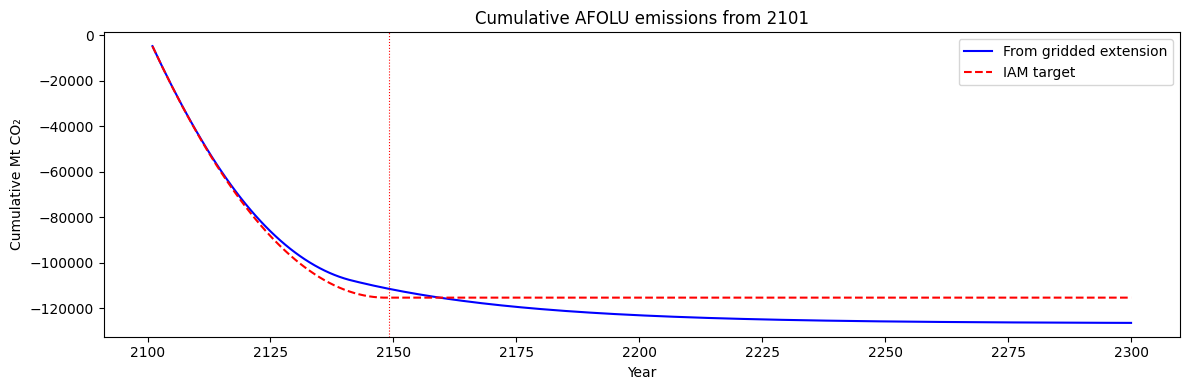

Cumulative by 2149:  gridded = -111392,  IAM = -115305 Mt CO₂
Cumulative by 2200:  gridded = -123069,  IAM = -115305 Mt CO₂


In [23]:
cum_calib = np.cumsum(ext_calib)
cum_iam = np.cumsum(iam_ext_vals)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(full_ext_years[:200], cum_calib[:200], 'b-', lw=1.5, label='From gridded extension')
ax.plot(full_ext_years[:200], cum_iam[:200], 'r--', lw=1.5, label='IAM target')
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Mt CO₂')
ax.set_title('Cumulative AFOLU emissions from 2101')
ax.legend()
plt.tight_layout(); plt.show()

idx_2149 = np.searchsorted(full_ext_years, 2149)
print(f'Cumulative by 2149:  gridded = {cum_calib[idx_2149]:.0f},  IAM = {cum_iam[idx_2149]:.0f} Mt CO₂')
print(f'Cumulative by 2200:  gridded = {cum_calib[99]:.0f},  IAM = {cum_iam[99]:.0f} Mt CO₂')

In [16]:
# Clean up
ds_ext.close()
ds_input.close()
print('All datasets closed.')

All datasets closed.
